<a href="https://colab.research.google.com/github/Gebarrdi/callao-prediccion-robos/blob/main/notebooks/01_EDA_Callao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ====================================================================
# CELDA 1: SETUP INICIAL
# Proyecto: Predicción de Robos al Paso en el Callao
# Autor: Gerson Barrientos · UTP 2026
# ====================================================================

# Importamos las librerías que usaremos en todo el análisis
import pandas as pd                # Manipulación de datos
import numpy as np                  # Operaciones numéricas
import matplotlib.pyplot as plt     # Gráficos
import seaborn as sns               # Gráficos estadísticos más bonitos

# Configuración visual de los gráficos
plt.style.use('seaborn-v0_8-darkgrid')  # Estilo profesional
sns.set_palette("husl")                  # Paleta de colores
plt.rcParams['figure.figsize'] = (12, 6) # Tamaño por defecto

# Conectamos Google Drive para acceder a los datos
from google.colab import drive
drive.mount('/content/drive')

print("✅ Setup completado. Drive conectado.")

Mounted at /content/drive
✅ Setup completado. Drive conectado.


In [ ]:
# ====================================================================
# CELDA 2: CARGAR EL DATASET (CORREGIDO)
# ====================================================================

# Ruta del archivo
ruta_csv = '/content/drive/MyDrive/proyecto_callao_ml/datos_crudos/sidpol_nacional/sidpol_2018_2026.csv'

# Cargamos con coma (separador estándar) y UTF-8
df = pd.read_csv(ruta_csv, sep=',', encoding='utf-8')

print(f"✅ Dataset cargado correctamente")
print(f"   Filas: {len(df):,}")
print(f"   Columnas: {len(df.columns)}")
print(f"\n📋 Nombres de columnas:")
print(df.columns.tolist())

# Vista previa
df.head()

✅ Dataset cargado correctamente
   Filas: 355,947
   Columnas: 8

📋 Nombres de columnas:
['ANIO', 'MES', 'DPTO_HECHO_NEW', 'PROV_HECHO', 'DIST_HECHO', 'UBIGEO_HECHO', 'P_MODALIDADES', 'cantidad']


,ANIO,MES,DPTO_HECHO_NEW,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,P_MODALIDADES,cantidad
0,2018,1,AMAZONAS,BAGUA,ARAMANGO,10202,Otros,6
1,2018,1,AMAZONAS,BAGUA,ARAMANGO,10202,Violencia contra la mujer e integrantes,1
2,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Estafa,2
3,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Hurto,25
4,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Otros,64


In [ ]:
# ====================================================================
# CELDA 3: INSPECCIÓN GENERAL DEL DATASET
# ====================================================================

# Vista de las primeras 5 filas (con print explícito)
print("=" * 80)
print("PRIMERAS 5 FILAS")
print("=" * 80)
print(df.head().to_string())

# Información técnica: tipos de datos, valores nulos, memoria
print("\n" + "=" * 80)
print("INFO TÉCNICA")
print("=" * 80)
df.info()

# Estadísticas de las columnas numéricas
print("\n" + "=" * 80)
print("ESTADÍSTICAS NUMÉRICAS")
print("=" * 80)
print(df.describe().to_string())

# Conteo de valores únicos por columna (importante para filtrar después)
print("\n" + "=" * 80)
print("VALORES ÚNICOS POR COLUMNA")
print("=" * 80)
for col in df.columns:
    n_unicos = df[col].nunique()
    print(f"  {col:25} → {n_unicos:>8,} valores únicos")

# Verificación de valores nulos
print("\n" + "=" * 80)
print("VALORES NULOS POR COLUMNA")
print("=" * 80)
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "  ✅ ¡No hay valores nulos!")

PRIMERAS 5 FILAS
   ANIO  MES DPTO_HECHO_NEW PROV_HECHO DIST_HECHO  UBIGEO_HECHO                            P_MODALIDADES  cantidad
0  2018    1       AMAZONAS      BAGUA   ARAMANGO         10202                                    Otros         6
1  2018    1       AMAZONAS      BAGUA   ARAMANGO         10202  Violencia contra la mujer e integrantes         1
2  2018    1       AMAZONAS      BAGUA      BAGUA         10201                                   Estafa         2
3  2018    1       AMAZONAS      BAGUA      BAGUA         10201                                    Hurto        25
4  2018    1       AMAZONAS      BAGUA      BAGUA         10201                                    Otros        64

INFO TÉCNICA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355947 entries, 0 to 355946
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   ANIO            355947 non-null  int64 
 1   MES             355947 non-nu

In [ ]:
# ====================================================================
# CELDA 4: ANÁLISIS DE MODALIDADES DELICTIVAS
# ====================================================================

# Ver TODAS las modalidades disponibles con su cantidad de registros
print("=" * 80)
print("LAS 7 MODALIDADES DELICTIVAS DEL DATASET")
print("=" * 80)

modalidades = df['P_MODALIDADES'].value_counts()
print(modalidades.to_string())

# Ver también la suma total de denuncias por modalidad
print("\n" + "=" * 80)
print("TOTAL DE DENUNCIAS POR MODALIDAD (suma de columna cantidad)")
print("=" * 80)
total_denuncias_x_modalidad = df.groupby('P_MODALIDADES')['cantidad'].sum().sort_values(ascending=False)
print(total_denuncias_x_modalidad.to_string())

# Visualización rápida
print("\n" + "=" * 80)
print("DISTRIBUCIÓN PORCENTUAL")
print("=" * 80)
pct = (total_denuncias_x_modalidad / total_denuncias_x_modalidad.sum() * 100).round(2)
for modalidad, porcentaje in pct.items():
    print(f"  {modalidad:50} {porcentaje:>6}%")

LAS 7 MODALIDADES DELICTIVAS DEL DATASET
P_MODALIDADES
Otros                                      104057
Violencia contra la mujer e integrantes     88119
Hurto                                       64902
Robo                                        42077
Estafa                                      29427
Extorsión                                   18801
Homicidio                                    8564

TOTAL DE DENUNCIAS POR MODALIDAD (suma de columna cantidad)
P_MODALIDADES
Otros                                      2688144
Violencia contra la mujer e integrantes    1864277
Hurto                                      1408214
Robo                                        753427
Estafa                                      205270
Extorsión                                   106729
Homicidio                                    15037

DISTRIBUCIÓN PORCENTUAL
  Otros                                               38.18%
  Violencia contra la mujer e integrantes             26.48%
  Hurto         

In [ ]:
# ====================================================================
# CELDA 5: FILTRAR CALLAO + MODALIDADES DE ROBO
# ====================================================================

# Filtro 1: Solo Provincia Constitucional del Callao
df_callao = df[df['DPTO_HECHO_NEW'] == 'CALLAO'].copy()
print(f"📍 Filtro 1 (Solo Callao): {len(df_callao):,} filas")

# Filtro 2: Solo Hurto + Robo (nuestra definición operacional de "robo al paso")
modalidades_robo = ['Hurto', 'Robo']
df_callao_robo = df_callao[df_callao['P_MODALIDADES'].isin(modalidades_robo)].copy()
print(f"🎯 Filtro 2 (+ Hurto/Robo): {len(df_callao_robo):,} filas")

# Verificación: ¿qué distritos del Callao tenemos?
print("\n" + "=" * 80)
print("DISTRITOS DEL CALLAO EN EL DATASET")
print("=" * 80)
distritos = df_callao_robo['DIST_HECHO'].unique()
print(f"Total: {len(distritos)} distritos")
for d in sorted(distritos):
    print(f"  • {d}")

# Verificación: rango temporal del filtrado
print("\n" + "=" * 80)
print("COBERTURA TEMPORAL")
print("=" * 80)
print(f"Año mínimo: {df_callao_robo['ANIO'].min()}")
print(f"Año máximo: {df_callao_robo['ANIO'].max()}")
print(f"Total denuncias agregadas: {df_callao_robo['cantidad'].sum():,}")

# Vista previa
print("\n" + "=" * 80)
print("PRIMERAS 10 FILAS DEL DATASET FILTRADO")
print("=" * 80)
print(df_callao_robo.head(10).to_string())

📍 Filtro 1 (Solo Callao): 0 filas
🎯 Filtro 2 (+ Hurto/Robo): 0 filas

DISTRITOS DEL CALLAO EN EL DATASET
Total: 0 distritos

COBERTURA TEMPORAL
Año mínimo: nan
Año máximo: nan
Total denuncias agregadas: 0

PRIMERAS 10 FILAS DEL DATASET FILTRADO
Empty DataFrame
Columns: [ANIO, MES, DPTO_HECHO_NEW, PROV_HECHO, DIST_HECHO, UBIGEO_HECHO, P_MODALIDADES, cantidad]
Index: []


In [ ]:
# ====================================================================
# CELDA DIAGNÓSTICO: ¿Cómo aparece "CALLAO" exactamente?
# ====================================================================

# Ver TODOS los valores únicos de la columna departamento
print("=" * 80)
print("VALORES ÚNICOS EN DPTO_HECHO_NEW (los 26 departamentos)")
print("=" * 80)
deptos = df['DPTO_HECHO_NEW'].unique()
for i, d in enumerate(sorted(deptos), 1):
    print(f"  {i:>2}. '{d}'  (longitud: {len(d)} caracteres)")

# Buscar cualquier valor que contenga "callao" (sin importar mayúsculas)
print("\n" + "=" * 80)
print("BÚSQUEDA INTELIGENTE DE 'CALLAO'")
print("=" * 80)
mascara_callao = df['DPTO_HECHO_NEW'].str.contains('callao', case=False, na=False)
posibles = df[mascara_callao]['DPTO_HECHO_NEW'].unique()
print(f"Valores que contienen 'callao': {posibles}")
print(f"Filas que coinciden: {mascara_callao.sum():,}")

VALORES ÚNICOS EN DPTO_HECHO_NEW (los 26 departamentos)
   1. 'AMAZONAS'  (longitud: 8 caracteres)
   2. 'ANCASH'  (longitud: 6 caracteres)
   3. 'APURIMAC'  (longitud: 8 caracteres)
   4. 'AREQUIPA'  (longitud: 8 caracteres)
   5. 'AYACUCHO'  (longitud: 8 caracteres)
   6. 'CAJAMARCA'  (longitud: 9 caracteres)
   7. 'CUSCO'  (longitud: 5 caracteres)
   8. 'HUANCAVELICA'  (longitud: 12 caracteres)
   9. 'HUANUCO'  (longitud: 7 caracteres)
  10. 'ICA'  (longitud: 3 caracteres)
  11. 'JUNIN'  (longitud: 5 caracteres)
  12. 'LA LIBERTAD'  (longitud: 11 caracteres)
  13. 'LAMBAYEQUE'  (longitud: 10 caracteres)
  14. 'LIMA METROPOLITANA'  (longitud: 18 caracteres)
  15. 'LORETO'  (longitud: 6 caracteres)
  16. 'MADRE DE DIOS'  (longitud: 13 caracteres)
  17. 'MOQUEGUA'  (longitud: 8 caracteres)
  18. 'PASCO'  (longitud: 5 caracteres)
  19. 'PIURA'  (longitud: 5 caracteres)
  20. 'PROV. CONST. DEL CALLAO'  (longitud: 23 caracteres)
  21. 'PUNO'  (longitud: 4 caracteres)
  22. 'REGION LIMA'  

In [ ]:
# ====================================================================
# CELDA 5: FILTRAR CALLAO + MODALIDADES DE ROBO (CORREGIDO)
# ====================================================================

# Filtro 1: Solo Provincia Constitucional del Callao
df_callao = df[df['DPTO_HECHO_NEW'] == 'PROV. CONST. DEL CALLAO'].copy()
print(f"📍 Filtro 1 (Solo Callao): {len(df_callao):,} filas")

# Filtro 2: Solo Hurto + Robo (definición operacional de "robo al paso")
modalidades_robo = ['Hurto', 'Robo']
df_callao_robo = df_callao[df_callao['P_MODALIDADES'].isin(modalidades_robo)].copy()
print(f"🎯 Filtro 2 (+ Hurto/Robo): {len(df_callao_robo):,} filas")

# Verificación: ¿qué distritos del Callao tenemos?
print("\n" + "=" * 80)
print("DISTRITOS DEL CALLAO EN EL DATASET")
print("=" * 80)
distritos = df_callao_robo['DIST_HECHO'].unique()
print(f"Total: {len(distritos)} distritos")
for d in sorted(distritos):
    n_registros = len(df_callao_robo[df_callao_robo['DIST_HECHO'] == d])
    total_denuncias = df_callao_robo[df_callao_robo['DIST_HECHO'] == d]['cantidad'].sum()
    print(f"  • {d:30} → {n_registros:>4} registros, {total_denuncias:>6,} denuncias totales")

# Verificación: rango temporal del filtrado
print("\n" + "=" * 80)
print("COBERTURA TEMPORAL")
print("=" * 80)
print(f"Año mínimo: {df_callao_robo['ANIO'].min()}")
print(f"Año máximo: {df_callao_robo['ANIO'].max()}")
print(f"Total denuncias agregadas: {df_callao_robo['cantidad'].sum():,}")

# Distribución por modalidad dentro del Callao
print("\n" + "=" * 80)
print("DISTRIBUCIÓN POR MODALIDAD EN CALLAO")
print("=" * 80)
print(df_callao_robo.groupby('P_MODALIDADES')['cantidad'].sum().sort_values(ascending=False).to_string())

# Vista previa
print("\n" + "=" * 80)
print("PRIMERAS 10 FILAS DEL DATASET FILTRADO")
print("=" * 80)
print(df_callao_robo.head(10).to_string())

📍 Filtro 1 (Solo Callao): 3,922 filas
🎯 Filtro 2 (+ Hurto/Robo): 1,242 filas

DISTRITOS DEL CALLAO EN EL DATASET
Total: 7 distritos
  • BELLAVISTA                     →  198 registros,  7,374 denuncias totales
  • CALLAO                         →  198 registros, 49,923 denuncias totales
  • CARMEN DE LA LEGUA REYNOSO     →  187 registros,  1,826 denuncias totales
  • LA PERLA                       →  196 registros,  3,310 denuncias totales
  • LA PUNTA                       →  119 registros,    288 denuncias totales
  • MI PERU                        →  146 registros,  1,128 denuncias totales
  • VENTANILLA                     →  198 registros, 11,821 denuncias totales

COBERTURA TEMPORAL
Año mínimo: 2018
Año máximo: 2026
Total denuncias agregadas: 75,670

DISTRIBUCIÓN POR MODALIDAD EN CALLAO
P_MODALIDADES
Hurto    42342
Robo     33328

PRIMERAS 10 FILAS DEL DATASET FILTRADO
      ANIO  MES           DPTO_HECHO_NEW PROV_HECHO                  DIST_HECHO  UBIGEO_HECHO P_MODALIDADES  can

💾 Dataset filtrado guardado en Drive
   Ruta: callao_robos_filtrado.csv
   Filas: 1,242


/tmp/ipykernel_3339/1971226265.py:31: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3339/1971226265.py:32: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Liberation Sans.
  plt.savefig('/content/drive/MyDrive/proyecto_callao_ml/outputs/01_denuncias_por_distrito.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


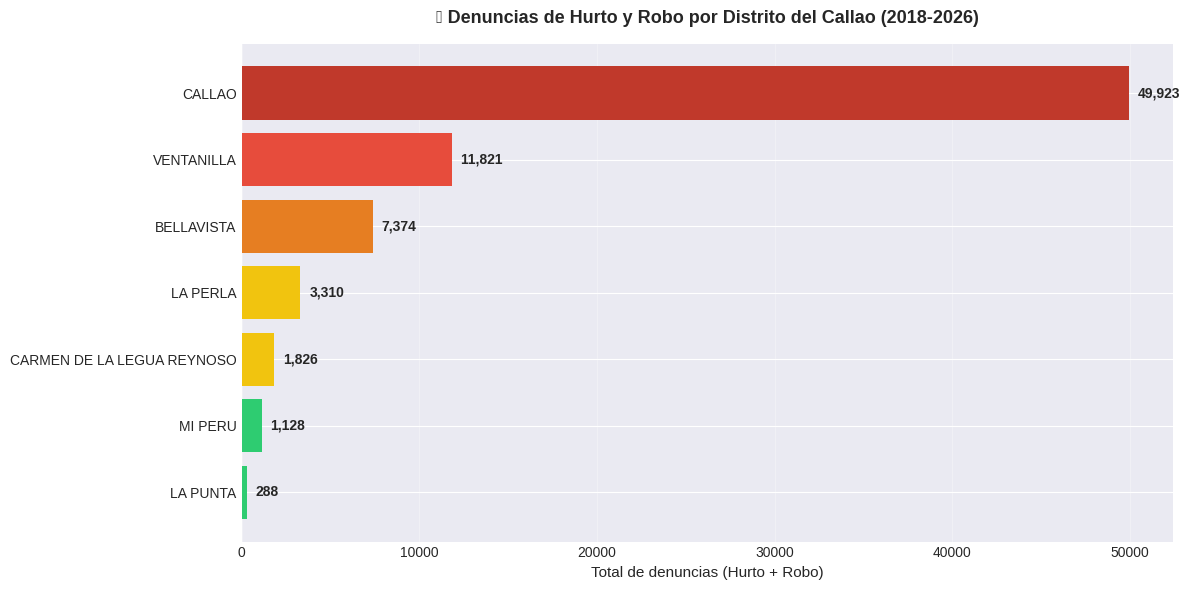


✅ Gráfico 1 guardado en outputs/01_denuncias_por_distrito.png


In [ ]:
# ====================================================================
# CELDA 6: GUARDAR DATASET FILTRADO + PRIMER GRÁFICO
# ====================================================================

# Guardamos el dataset filtrado en Drive para usarlo después
ruta_salida = '/content/drive/MyDrive/proyecto_callao_ml/datos_crudos/sidpol_nacional/callao_robos_filtrado.csv'
df_callao_robo.to_csv(ruta_salida, index=False, encoding='utf-8')
print(f"💾 Dataset filtrado guardado en Drive")
print(f"   Ruta: callao_robos_filtrado.csv")
print(f"   Filas: {len(df_callao_robo):,}")

# ────────────────────────────────────────────────────────────────────
# GRÁFICO 1: Total de denuncias por distrito
# ────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 6))
denuncias_distrito = df_callao_robo.groupby('DIST_HECHO')['cantidad'].sum().sort_values(ascending=True)

# Colores: rojo para los más críticos, verde para los más seguros
colores = ['#2ecc71', '#2ecc71', '#f1c40f', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b']
ax.barh(denuncias_distrito.index, denuncias_distrito.values, color=colores)

# Etiquetas con valores numéricos
for i, v in enumerate(denuncias_distrito.values):
    ax.text(v + 500, i, f'{v:,}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Total de denuncias (Hurto + Robo)', fontsize=11)
ax.set_title('🔍 Denuncias de Hurto y Robo por Distrito del Callao (2018-2026)',
             fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/proyecto_callao_ml/outputs/01_denuncias_por_distrito.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico 1 guardado en outputs/01_denuncias_por_distrito.png")

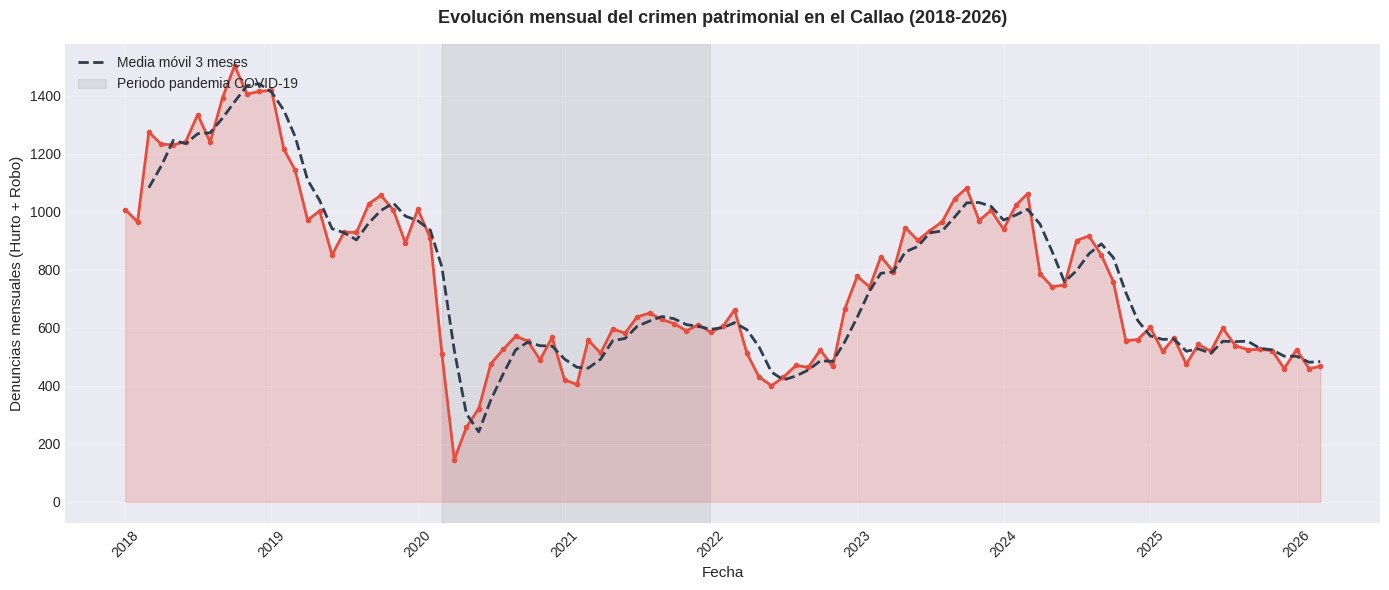


INSIGHTS TEMPORALES CLAVE
📅 Mes con MÁS denuncias: October 2018 → 1,503 denuncias
📅 Mes con MENOS denuncias: April 2020 → 145 denuncias
📊 Promedio mensual histórico: 764 denuncias
📊 Promedio pre-pandemia (2018-2019): 1138
📊 Promedio durante pandemia (2020-2021): 509
📊 Promedio post-pandemia (2022+): 686


In [ ]:
# ====================================================================
# CELDA 7: EVOLUCIÓN TEMPORAL DEL CRIMEN
# ====================================================================

# Creamos columna de fecha para el eje X
df_callao_robo['FECHA'] = pd.to_datetime(
    df_callao_robo['ANIO'].astype(str) + '-' + df_callao_robo['MES'].astype(str) + '-01'
)

# Agregamos por mes (sumando todos los distritos y modalidades)
evolucion_mensual = df_callao_robo.groupby('FECHA')['cantidad'].sum().reset_index()

# Gráfico de línea con áreas sombreadas por año
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(evolucion_mensual['FECHA'], evolucion_mensual['cantidad'],
        color='#e74c3c', linewidth=2, marker='o', markersize=3)
ax.fill_between(evolucion_mensual['FECHA'], evolucion_mensual['cantidad'],
                alpha=0.2, color='#e74c3c')

# Línea de tendencia (media móvil 3 meses)
evolucion_mensual['MA3'] = evolucion_mensual['cantidad'].rolling(window=3).mean()
ax.plot(evolucion_mensual['FECHA'], evolucion_mensual['MA3'],
        color='#2c3e50', linewidth=2, linestyle='--', label='Media móvil 3 meses')

# Anotación del periodo pandemia
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
           alpha=0.15, color='gray', label='Periodo pandemia COVID-19')

ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Denuncias mensuales (Hurto + Robo)', fontsize=11)
ax.set_title('Evolución mensual del crimen patrimonial en el Callao (2018-2026)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/proyecto_callao_ml/outputs/02_evolucion_temporal.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas clave para tu informe
print("\n" + "=" * 80)
print("INSIGHTS TEMPORALES CLAVE")
print("=" * 80)
print(f"📅 Mes con MÁS denuncias: {evolucion_mensual.loc[evolucion_mensual['cantidad'].idxmax(), 'FECHA'].strftime('%B %Y')} → {evolucion_mensual['cantidad'].max():,} denuncias")
print(f"📅 Mes con MENOS denuncias: {evolucion_mensual.loc[evolucion_mensual['cantidad'].idxmin(), 'FECHA'].strftime('%B %Y')} → {evolucion_mensual['cantidad'].min():,} denuncias")
print(f"📊 Promedio mensual histórico: {evolucion_mensual['cantidad'].mean():.0f} denuncias")
print(f"📊 Promedio pre-pandemia (2018-2019): {evolucion_mensual[evolucion_mensual['FECHA'] < '2020-03-01']['cantidad'].mean():.0f}")
print(f"📊 Promedio durante pandemia (2020-2021): {evolucion_mensual[(evolucion_mensual['FECHA'] >= '2020-03-01') & (evolucion_mensual['FECHA'] <= '2021-12-31')]['cantidad'].mean():.0f}")
print(f"📊 Promedio post-pandemia (2022+): {evolucion_mensual[evolucion_mensual['FECHA'] > '2022-01-01']['cantidad'].mean():.0f}")

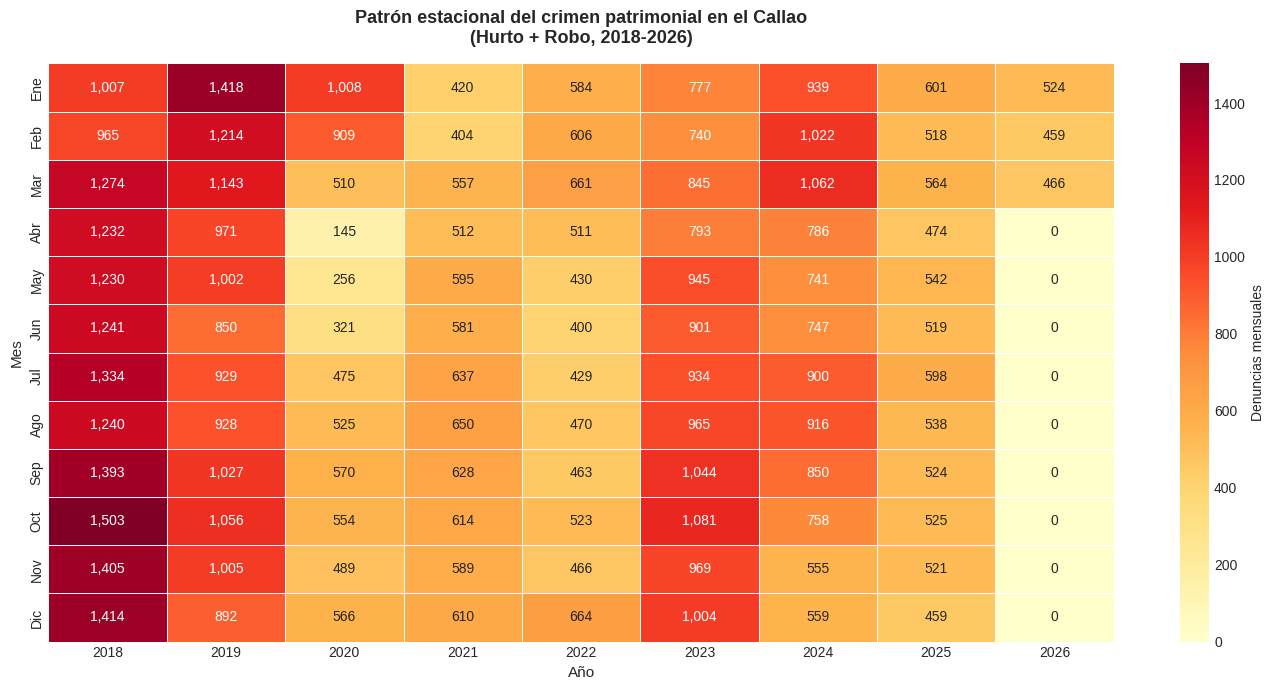


INSIGHTS ESTACIONALES

🗓️  RANKING DE MESES MÁS PELIGROSOS (promedio histórico)
   1. Ene: 7,278 denuncias acumuladas en 8 años
   2. Mar: 7,082 denuncias acumuladas en 8 años
   3. Feb: 6,837 denuncias acumuladas en 8 años
   4. Oct: 6,614 denuncias acumuladas en 8 años
   5. Sep: 6,499 denuncias acumuladas en 8 años
   6. Jul: 6,236 denuncias acumuladas en 8 años
   7. Ago: 6,232 denuncias acumuladas en 8 años
   8. Dic: 6,168 denuncias acumuladas en 8 años
   9. Nov: 5,999 denuncias acumuladas en 8 años
  10. May: 5,741 denuncias acumuladas en 8 años
  11. Jun: 5,560 denuncias acumuladas en 8 años
  12. Abr: 5,424 denuncias acumuladas en 8 años

📊 Mes más peligroso del año: Ene (7,278 acumuladas)
📊 Mes más seguro del año: Abr (5,424 acumuladas)
📊 Diferencia: 34.2% más en el peor mes


In [ ]:
# ====================================================================
# CELDA 8: HEATMAP DE PATRONES ESTACIONALES (MES vs AÑO)
# ====================================================================

# Pivot: filas = MES, columnas = ANIO, valores = total denuncias
heatmap_data = df_callao_robo.pivot_table(
    index='MES',
    columns='ANIO',
    values='cantidad',
    aggfunc='sum',
    fill_value=0
)

# Etiquetas legibles para los meses
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
heatmap_data.index = nombres_meses[:len(heatmap_data)]

# Crear el heatmap
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(heatmap_data,
            annot=True,           # mostrar números en cada celda
            fmt=',.0f',            # formato sin decimales con coma
            cmap='YlOrRd',         # paleta amarillo-naranja-rojo
            cbar_kws={'label': 'Denuncias mensuales'},
            linewidths=0.5,
            linecolor='white',
            ax=ax)

ax.set_title('Patrón estacional del crimen patrimonial en el Callao\n(Hurto + Robo, 2018-2026)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Mes', fontsize=11)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/proyecto_callao_ml/outputs/03_heatmap_estacional.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Insights estacionales
print("\n" + "=" * 80)
print("INSIGHTS ESTACIONALES")
print("=" * 80)

# Promedio por mes (a través de todos los años)
promedio_por_mes = df_callao_robo.groupby('MES')['cantidad'].sum().sort_values(ascending=False)
print("\n🗓️  RANKING DE MESES MÁS PELIGROSOS (promedio histórico)")
for i, (mes_num, total) in enumerate(promedio_por_mes.items(), 1):
    nombre_mes = nombres_meses[mes_num - 1]
    print(f"  {i:>2}. {nombre_mes}: {total:,} denuncias acumuladas en 8 años")

# Diferencia entre el mes más peligroso y el más seguro
mas_peligroso = promedio_por_mes.idxmax()
mas_seguro = promedio_por_mes.idxmin()
print(f"\n📊 Mes más peligroso del año: {nombres_meses[mas_peligroso-1]} ({promedio_por_mes.max():,} acumuladas)")
print(f"📊 Mes más seguro del año: {nombres_meses[mas_seguro-1]} ({promedio_por_mes.min():,} acumuladas)")
print(f"📊 Diferencia: {((promedio_por_mes.max() / promedio_por_mes.min()) - 1) * 100:.1f}% más en el peor mes")

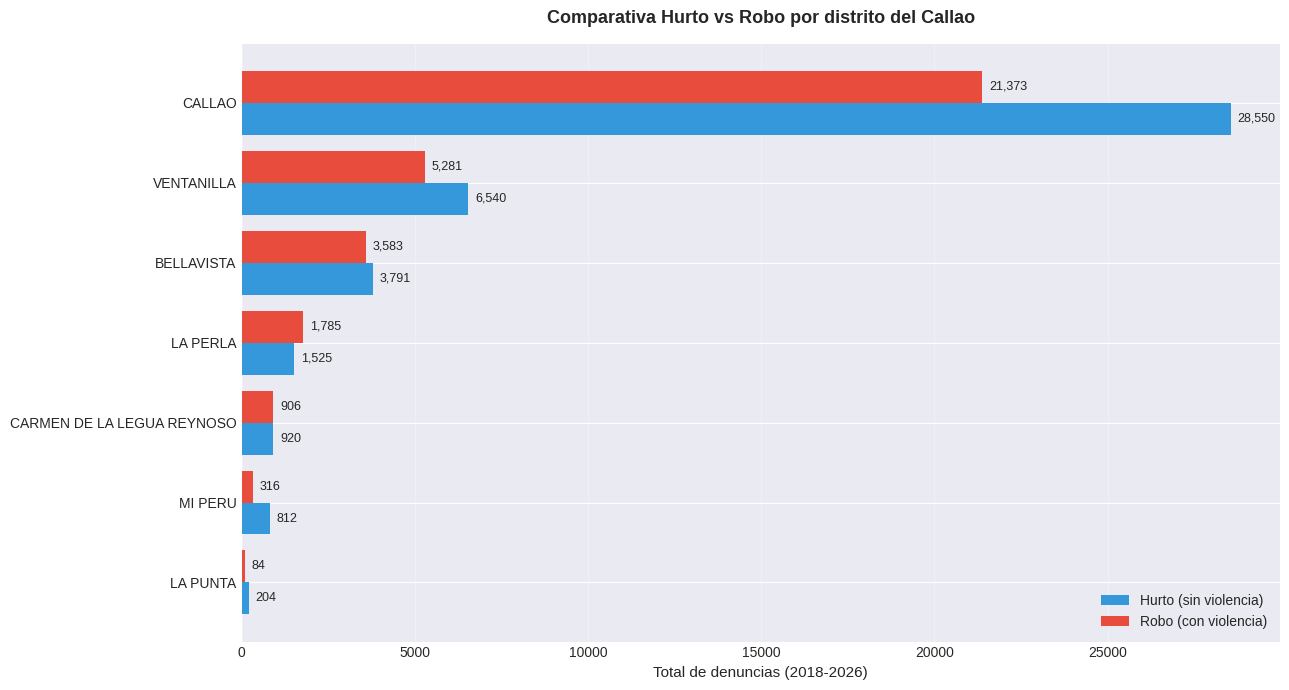


RATIO HURTO/ROBO POR DISTRITO
(Ratio > 1: predomina hurto sin violencia)
(Ratio < 1: predomina robo con violencia)

P_MODALIDADES               Hurto   Robo  Ratio_Hurto_Robo
DIST_HECHO                                                
MI PERU                       812    316              2.57
LA PUNTA                      204     84              2.43
CALLAO                      28550  21373              1.34
VENTANILLA                   6540   5281              1.24
BELLAVISTA                   3791   3583              1.06
CARMEN DE LA LEGUA REYNOSO    920    906              1.02
LA PERLA                     1525   1785              0.85

💡 INTERPRETACIÓN CRIMINOLÓGICA:
   Ratios altos = zonas comerciales/turísticas (más hurto al descuido)
   Ratios bajos = zonas con mayor inseguridad estructural (más violencia)


In [ ]:
# ====================================================================
# CELDA 9: COMPARATIVA HURTO vs ROBO POR DISTRITO
# ====================================================================

# Gráfico de barras agrupadas: cada distrito separado por modalidad
modalidad_distrito = df_callao_robo.pivot_table(
    index='DIST_HECHO',
    columns='P_MODALIDADES',
    values='cantidad',
    aggfunc='sum',
    fill_value=0
).sort_values('Hurto', ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))

x = np.arange(len(modalidad_distrito.index))
width = 0.4

barras1 = ax.barh(x - width/2, modalidad_distrito['Hurto'], width,
                   label='Hurto (sin violencia)', color='#3498db')
barras2 = ax.barh(x + width/2, modalidad_distrito['Robo'], width,
                   label='Robo (con violencia)', color='#e74c3c')

# Etiquetas en las barras
for barra in barras1:
    width_val = barra.get_width()
    ax.text(width_val + 200, barra.get_y() + barra.get_height()/2,
            f'{int(width_val):,}', va='center', fontsize=9)
for barra in barras2:
    width_val = barra.get_width()
    ax.text(width_val + 200, barra.get_y() + barra.get_height()/2,
            f'{int(width_val):,}', va='center', fontsize=9)

ax.set_yticks(x)
ax.set_yticklabels(modalidad_distrito.index)
ax.set_xlabel('Total de denuncias (2018-2026)', fontsize=11)
ax.set_title('Comparativa Hurto vs Robo por distrito del Callao',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/proyecto_callao_ml/outputs/04_hurto_vs_robo.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Ratio Hurto/Robo por distrito (insight criminológico)
print("\n" + "=" * 80)
print("RATIO HURTO/ROBO POR DISTRITO")
print("=" * 80)
print("(Ratio > 1: predomina hurto sin violencia)")
print("(Ratio < 1: predomina robo con violencia)\n")

modalidad_distrito['Ratio_Hurto_Robo'] = (modalidad_distrito['Hurto'] /
                                          modalidad_distrito['Robo']).round(2)
ranking = modalidad_distrito[['Hurto', 'Robo', 'Ratio_Hurto_Robo']].sort_values(
    'Ratio_Hurto_Robo', ascending=False)
print(ranking.to_string())

print("\n💡 INTERPRETACIÓN CRIMINOLÓGICA:")
print("   Ratios altos = zonas comerciales/turísticas (más hurto al descuido)")
print("   Ratios bajos = zonas con mayor inseguridad estructural (más violencia)")

In [ ]:
# ====================================================================
# CELDA 10: RESUMEN FINAL DEL SPRINT 1
# ====================================================================

print("=" * 80)
print("📊 RESUMEN EJECUTIVO DEL SPRINT 1")
print("=" * 80)

print(f"""
✅ DATASET FILTRADO
   • Filas finales: {len(df_callao_robo):,}
   • Distritos: 7 (todos los del Callao)
   • Modalidades: Hurto + Robo
   • Cobertura temporal: {df_callao_robo['ANIO'].min()} - {df_callao_robo['ANIO'].max()} ({df_callao_robo['ANIO'].max() - df_callao_robo['ANIO'].min() + 1} años)
   • Total denuncias: {df_callao_robo['cantidad'].sum():,}

✅ VISUALIZACIONES GENERADAS
   • 01_denuncias_por_distrito.png
   • 02_evolucion_temporal.png
   • 03_heatmap_estacional.png
   • 04_hurto_vs_robo.png

✅ INSIGHTS CLAVE PARA EL MODELO
   • Hot spot: Callao Cercado concentra 66% del crimen
   • Mes más peligroso: Enero (7,278 denuncias acumuladas)
   • Pandemia redujo crimen 55% (recuperación parcial post-2022)
   • Anomalía: La Perla es único distrito con más robo que hurto

✅ VARIABLES IDENTIFICADAS PARA EL MODELO
   • Variable objetivo: cantidad
   • Predictoras: ANIO, MES, DIST_HECHO, UBIGEO_HECHO, P_MODALIDADES

⏭️  PRÓXIMO SPRINT (mañana sábado)
   • Feature engineering (variables derivadas)
   • Train/test split
   • Entrenar Random Forest + Regresión Logística
   • Evaluar métricas
   • Generar mapa de calor con folium
""")

print("=" * 80)
print("🎯 SPRINT 1 COMPLETADO. Buen trabajo, papu! 🚀")
print("=" * 80)

📊 RESUMEN EJECUTIVO DEL SPRINT 1

✅ DATASET FILTRADO
   • Filas finales: 1,242
   • Distritos: 7 (todos los del Callao)
   • Modalidades: Hurto + Robo
   • Cobertura temporal: 2018 - 2026 (9 años)
   • Total denuncias: 75,670

✅ VISUALIZACIONES GENERADAS
   • 01_denuncias_por_distrito.png
   • 02_evolucion_temporal.png
   • 03_heatmap_estacional.png
   • 04_hurto_vs_robo.png

✅ INSIGHTS CLAVE PARA EL MODELO
   • Hot spot: Callao Cercado concentra 66% del crimen
   • Mes más peligroso: Enero (7,278 denuncias acumuladas)
   • Pandemia redujo crimen 55% (recuperación parcial post-2022)
   • Anomalía: La Perla es único distrito con más robo que hurto

✅ VARIABLES IDENTIFICADAS PARA EL MODELO
   • Variable objetivo: cantidad
   • Predictoras: ANIO, MES, DIST_HECHO, UBIGEO_HECHO, P_MODALIDADES

⏭️  PRÓXIMO SPRINT (mañana sábado)
   • Feature engineering (variables derivadas)
   • Train/test split
   • Entrenar Random Forest + Regresión Logística
   • Evaluar métricas
   • Generar mapa de cal

In [ ]:
# ====================================================================
# CELDA 10: FEATURE ENGINEERING + RANDOM FOREST
# ====================================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib

# ────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING
# ────────────────────────────────────────────────────────────────────

df_modelo = df_callao_robo.copy()

# Excluir meses futuros 2026 (que aparecen como 0 pero no son ceros reales)
df_modelo = df_modelo[~((df_modelo['ANIO'] == 2026) & (df_modelo['MES'] > 3))]

# Variables temporales derivadas
df_modelo['TRIMESTRE'] = ((df_modelo['MES'] - 1) // 3) + 1
df_modelo['SEMESTRE'] = ((df_modelo['MES'] - 1) // 6) + 1
df_modelo['ES_PANDEMIA'] = ((df_modelo['ANIO'] == 2020) |
                             ((df_modelo['ANIO'] == 2021) & (df_modelo['MES'] <= 12))).astype(int)
df_modelo['ES_VERANO'] = df_modelo['MES'].isin([1, 2, 3]).astype(int)
df_modelo['ES_DICIEMBRE'] = (df_modelo['MES'] == 12).astype(int)

# Codificación de variables categóricas
le_distrito = LabelEncoder()
le_modalidad = LabelEncoder()
df_modelo['DIST_ENCODED'] = le_distrito.fit_transform(df_modelo['DIST_HECHO'])
df_modelo['MODALIDAD_ENCODED'] = le_modalidad.fit_transform(df_modelo['P_MODALIDADES'])

print("✅ Feature engineering completado")
print(f"   Filas para modelado: {len(df_modelo):,}")

# Variables predictoras y objetivo
features = ['ANIO', 'MES', 'TRIMESTRE', 'SEMESTRE', 'ES_PANDEMIA',
            'ES_VERANO', 'ES_DICIEMBRE', 'DIST_ENCODED', 'MODALIDAD_ENCODED', 'UBIGEO_HECHO']
X = df_modelo[features]
y = df_modelo['cantidad']

# Train/Test Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n🔀 Train/Test Split:")
print(f"   Entrenamiento: {len(X_train):,} filas")
print(f"   Prueba:        {len(X_test):,} filas")

# ────────────────────────────────────────────────────────────────────
# RANDOM FOREST
# ────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("🌲 ENTRENANDO RANDOM FOREST...")
print("=" * 70)

modelo_rf = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_split=5,
    random_state=42, n_jobs=-1
)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\n📊 RANDOM FOREST:")
print(f"   MAE:  {mae_rf:.2f} denuncias")
print(f"   RMSE: {rmse_rf:.2f} denuncias")
print(f"   R²:   {r2_rf:.4f} ({r2_rf*100:.2f}%)")

# ────────────────────────────────────────────────────────────────────
# REGRESIÓN LINEAL (BASELINE)
# ────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("📐 REGRESIÓN LINEAL (BASELINE)...")
print("=" * 70)

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"\n📊 REGRESIÓN LINEAL:")
print(f"   MAE:  {mae_lr:.2f} denuncias")
print(f"   RMSE: {rmse_lr:.2f} denuncias")
print(f"   R²:   {r2_lr:.4f} ({r2_lr*100:.2f}%)")

# ────────────────────────────────────────────────────────────────────
# COMPARACIÓN
# ────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("🏆 COMPARACIÓN")
print("=" * 70)
print(f"\n   {'Métrica':<10} {'RF':>15} {'Lineal':>15} {'Mejora':>12}")
print(f"   {'-'*55}")
print(f"   {'MAE':<10} {mae_rf:>15.2f} {mae_lr:>15.2f} {((mae_lr-mae_rf)/mae_lr*100):>+11.1f}%")
print(f"   {'RMSE':<10} {rmse_rf:>15.2f} {rmse_lr:>15.2f} {((rmse_lr-rmse_rf)/rmse_lr*100):>+11.1f}%")
print(f"   {'R²':<10} {r2_rf:>15.4f} {r2_lr:>15.4f} {((r2_rf-r2_lr)/abs(r2_lr)*100):>+11.1f}%")

ganador = "🌲 RANDOM FOREST" if r2_rf > r2_lr else "📐 REGRESIÓN LINEAL"
print(f"\n   🏆 GANADOR: {ganador}")

# ────────────────────────────────────────────────────────────────────
# IMPORTANCIA DE VARIABLES
# ────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("🎯 IMPORTANCIA DE VARIABLES")
print("=" * 70)

importancias = pd.DataFrame({
    'Variable': features,
    'Importancia': modelo_rf.feature_importances_
}).sort_values('Importancia', ascending=False)

for _, row in importancias.iterrows():
    barra = '█' * int(row['Importancia'] * 50)
    print(f"   {row['Variable']:20} {row['Importancia']:.4f}  {barra}")

# ────────────────────────────────────────────────────────────────────
# GUARDAR MODELO Y ENCODERS
# ────────────────────────────────────────────────────────────────────
joblib.dump(modelo_rf, '/content/drive/MyDrive/proyecto_callao_ml/outputs/modelo_callao_rf.pkl')
joblib.dump(le_distrito, '/content/drive/MyDrive/proyecto_callao_ml/outputs/encoder_distrito.pkl')
joblib.dump(le_modalidad, '/content/drive/MyDrive/proyecto_callao_ml/outputs/encoder_modalidad.pkl')
print("\n💾 Modelo y encoders guardados en outputs/")

✅ Feature engineering completado
   Filas para modelado: 1,242

🔀 Train/Test Split:
   Entrenamiento: 993 filas
   Prueba:        249 filas

🌲 ENTRENANDO RANDOM FOREST...

📊 RANDOM FOREST:
   MAE:  13.54 denuncias
   RMSE: 26.52 denuncias
   R²:   0.9258 (92.58%)

📐 REGRESIÓN LINEAL (BASELINE)...

📊 REGRESIÓN LINEAL:
   MAE:  47.94 denuncias
   RMSE: 63.87 denuncias
   R²:   0.5694 (56.94%)

🏆 COMPARACIÓN

   Métrica                 RF          Lineal       Mejora
   -------------------------------------------------------
   MAE                  13.54           47.94       +71.8%
   RMSE                 26.52           63.87       +58.5%
   R²                  0.9258          0.5694       +62.6%

   🏆 GANADOR: 🌲 RANDOM FOREST

🎯 IMPORTANCIA DE VARIABLES
   UBIGEO_HECHO         0.7845  ███████████████████████████████████████
   ANIO                 0.1249  ██████
   DIST_ENCODED         0.0328  █
   MES                  0.0248  █
   MODALIDAD_ENCODED    0.0235  █
   TRIMESTRE           

In [2]:
# ====================================================================
# DIAGNÓSTICO: ¿Drive conectado? ¿Dónde está el modelo?
# ====================================================================

import os
from google.colab import drive

# Reconectar Drive (por si se desconectó)
drive.mount('/content/drive', force_remount=True)

# Verificar carpeta del proyecto
ruta_proyecto = '/content/drive/MyDrive/proyecto_callao_ml'
print(f"\n📁 ¿Existe la carpeta del proyecto?")
print(f"   {ruta_proyecto}: {os.path.exists(ruta_proyecto)}")

# Listar contenido de la carpeta del proyecto
if os.path.exists(ruta_proyecto):
    print(f"\n📂 Contenido de proyecto_callao_ml/:")
    for item in sorted(os.listdir(ruta_proyecto)):
        print(f"   • {item}")

# Verificar carpeta outputs
ruta_outputs = '/content/drive/MyDrive/proyecto_callao_ml/outputs'
print(f"\n📁 ¿Existe outputs?")
print(f"   {ruta_outputs}: {os.path.exists(ruta_outputs)}")

if os.path.exists(ruta_outputs):
    print(f"\n📂 Contenido de outputs/:")
    archivos = sorted(os.listdir(ruta_outputs))
    for item in archivos:
        ruta_completa = os.path.join(ruta_outputs, item)
        size_kb = os.path.getsize(ruta_completa) / 1024
        print(f"   • {item} ({size_kb:.1f} KB)")

    # Buscar específicamente archivos .pkl
    pkl_files = [f for f in archivos if f.endswith('.pkl')]
    if pkl_files:
        print(f"\n✅ Archivos .pkl encontrados: {pkl_files}")
    else:
        print(f"\n❌ NO hay archivos .pkl en outputs/")
        print(f"   Tendremos que re-entrenar el modelo.")

Mounted at /content/drive

📁 ¿Existe la carpeta del proyecto?
   /content/drive/MyDrive/proyecto_callao_ml: True

📂 Contenido de proyecto_callao_ml/:
   • datos_crudos
   • notebooks
   • outputs

📁 ¿Existe outputs?
   /content/drive/MyDrive/proyecto_callao_ml/outputs: True

📂 Contenido de outputs/:
   • 01_denuncias_por_distrito.png (63.0 KB)
   • 02_evolucion_temporal.png (151.5 KB)
   • 03_heatmap_estacional.png (165.1 KB)
   • 04_hurto_vs_robo.png (75.8 KB)
   • encoder_distrito.pkl (0.6 KB)
   • encoder_modalidad.pkl (0.5 KB)
   • modelo_callao_rf.pkl (6750.7 KB)

✅ Archivos .pkl encontrados: ['encoder_distrito.pkl', 'encoder_modalidad.pkl', 'modelo_callao_rf.pkl']


✅ Modelo y encoders cargados
✅ 126 predicciones generadas para 2026 (abril-diciembre)

📊 PREDICCIONES DE DENUNCIAS POR DISTRITO Y MES (Abril-Diciembre 2026)
                            Abr  May  Jun  Jul  Ago  Sep  Oct  Nov  Dic  TOTAL
DISTRITO                                                                      
CALLAO                      348  372  374  384  387  362  359  361  360   3307
VENTANILLA                   54   53   51   63   71   76   75   72   57    572
BELLAVISTA                   39   38   39   38   38   42   39   38   38    349
LA PERLA                     22   23   22   25   25   29   28   26   26    226
CARMEN DE LA LEGUA REYNOSO   14   14   15   15   18   19   20   17   18    150
MI PERU                      11   10   11   11    8    8   10    8    8     85
LA PUNTA                      4    4    3    4    4    3    4    5    5     36
TOTAL                       492  514  515  540  551  539  535  527  512   4725

💾 Tabla guardada en outputs/predicciones_2026.csv


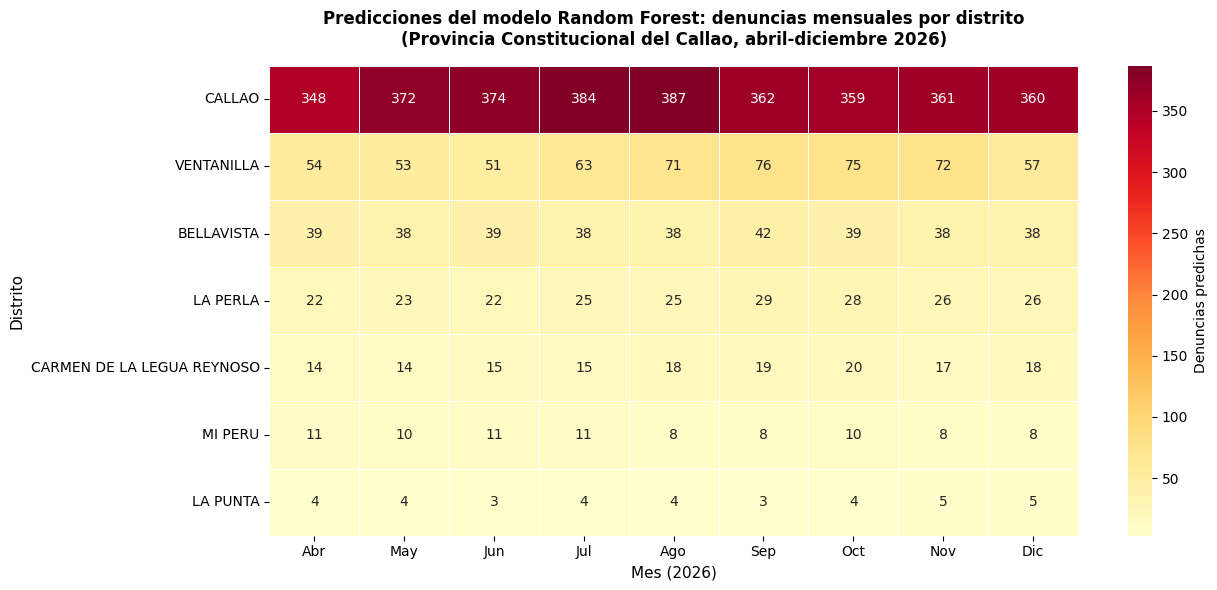


💾 Heatmap guardado en outputs/05_predicciones_2026.png

🔍 INSIGHTS DE LAS PREDICCIONES

📈 Mes con mayor predicción de denuncias: Ago 2026 (551 denuncias totales)
📈 Distrito de mayor riesgo predicho: CALLAO (3,307 denuncias en 9 meses)
📊 Total de denuncias predichas (abr-dic 2026): 4,725
📊 Promedio mensual predicho: 525 denuncias/mes

🚨 TOP 3 CRUCES CRÍTICOS (mayor riesgo predicho):
   CALLAO                         Ago 2026: 387 denuncias
   CALLAO                         Jul 2026: 384 denuncias
   CALLAO                         Jun 2026: 374 denuncias


In [3]:
# ====================================================================
# CELDA 11: PREDICCIONES REALES DEL MODELO
# Generar predicciones para meses futuros y crear visualizaciones
# ====================================================================

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar modelo y encoders ya entrenados
modelo_rf = joblib.load('/content/drive/MyDrive/proyecto_callao_ml/outputs/modelo_callao_rf.pkl')
le_distrito = joblib.load('/content/drive/MyDrive/proyecto_callao_ml/outputs/encoder_distrito.pkl')
le_modalidad = joblib.load('/content/drive/MyDrive/proyecto_callao_ml/outputs/encoder_modalidad.pkl')

print("✅ Modelo y encoders cargados")

# ────────────────────────────────────────────────────────────────────
# CREAR ESCENARIOS DE PREDICCIÓN: 2026 completo (abril - diciembre)
# ────────────────────────────────────────────────────────────────────

# Mapeo manual de distrito → ubigeo (de tus datos)
distrito_ubigeo = {
    'BELLAVISTA': 70102,
    'CALLAO': 70101,
    'CARMEN DE LA LEGUA REYNOSO': 70103,
    'LA PERLA': 70104,
    'LA PUNTA': 70105,
    'MI PERU': 70107,
    'VENTANILLA': 70106
}

# Generar todas las combinaciones distrito × mes × modalidad para 2026
predicciones = []
for distrito, ubigeo in distrito_ubigeo.items():
    for mes in range(4, 13):  # Abril a Diciembre 2026
        for modalidad in ['Hurto', 'Robo']:
            predicciones.append({
                'ANIO': 2026,
                'MES': mes,
                'TRIMESTRE': ((mes - 1) // 3) + 1,
                'SEMESTRE': ((mes - 1) // 6) + 1,
                'ES_PANDEMIA': 0,
                'ES_VERANO': 1 if mes in [1,2,3] else 0,
                'ES_DICIEMBRE': 1 if mes == 12 else 0,
                'DIST_ENCODED': le_distrito.transform([distrito])[0],
                'MODALIDAD_ENCODED': le_modalidad.transform([modalidad])[0],
                'UBIGEO_HECHO': ubigeo,
                'DISTRITO': distrito,
                'MODALIDAD': modalidad
            })

df_pred = pd.DataFrame(predicciones)

# Hacer las predicciones
features = ['ANIO', 'MES', 'TRIMESTRE', 'SEMESTRE', 'ES_PANDEMIA',
            'ES_VERANO', 'ES_DICIEMBRE', 'DIST_ENCODED', 'MODALIDAD_ENCODED', 'UBIGEO_HECHO']
df_pred['DENUNCIAS_PREDICHAS'] = modelo_rf.predict(df_pred[features]).round().astype(int)

# Eliminar predicciones negativas (si las hubiera)
df_pred['DENUNCIAS_PREDICHAS'] = df_pred['DENUNCIAS_PREDICHAS'].clip(lower=0)

print(f"✅ {len(df_pred)} predicciones generadas para 2026 (abril-diciembre)")

# ────────────────────────────────────────────────────────────────────
# TABLA RESUMEN: Predicciones consolidadas por distrito y mes (Hurto + Robo)
# ────────────────────────────────────────────────────────────────────

tabla_resumen = df_pred.pivot_table(
    index='DISTRITO',
    columns='MES',
    values='DENUNCIAS_PREDICHAS',
    aggfunc='sum',  # Suma Hurto + Robo
    fill_value=0
)

# Etiquetas legibles
nombres_meses = {4:'Abr', 5:'May', 6:'Jun', 7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
tabla_resumen.columns = [nombres_meses[m] for m in tabla_resumen.columns]

# Agregar fila de total y columna de total
tabla_resumen.loc['TOTAL'] = tabla_resumen.sum()
tabla_resumen['TOTAL'] = tabla_resumen.sum(axis=1)

# Ordenar por total descendente (excepto la fila TOTAL al final)
tabla_total_row = tabla_resumen.loc['TOTAL']
tabla_resumen = tabla_resumen.drop('TOTAL').sort_values('TOTAL', ascending=False)
tabla_resumen.loc['TOTAL'] = tabla_total_row

print("\n" + "=" * 80)
print("📊 PREDICCIONES DE DENUNCIAS POR DISTRITO Y MES (Abril-Diciembre 2026)")
print("=" * 80)
print(tabla_resumen.to_string())

# Guardar tabla como CSV
tabla_resumen.to_csv('/content/drive/MyDrive/proyecto_callao_ml/outputs/predicciones_2026.csv')
print("\n💾 Tabla guardada en outputs/predicciones_2026.csv")

# ────────────────────────────────────────────────────────────────────
# HEATMAP DE PREDICCIONES (Distrito × Mes)
# ────────────────────────────────────────────────────────────────────

# Quitar la fila TOTAL para el heatmap
tabla_heatmap = tabla_resumen.drop('TOTAL').drop(columns='TOTAL')

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(tabla_heatmap,
            annot=True,
            fmt=',.0f',
            cmap='YlOrRd',
            cbar_kws={'label': 'Denuncias predichas'},
            linewidths=0.5,
            linecolor='white',
            ax=ax)

ax.set_title('Predicciones del modelo Random Forest: denuncias mensuales por distrito\n(Provincia Constitucional del Callao, abril-diciembre 2026)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Mes (2026)', fontsize=11)
ax.set_ylabel('Distrito', fontsize=11)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/proyecto_callao_ml/outputs/05_predicciones_2026.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Heatmap guardado en outputs/05_predicciones_2026.png")

# ────────────────────────────────────────────────────────────────────
# INSIGHTS DE LAS PREDICCIONES
# ────────────────────────────────────────────────────────────────────

print("\n" + "=" * 80)
print("🔍 INSIGHTS DE LAS PREDICCIONES")
print("=" * 80)

# Mes con más denuncias predichas (sumando todos los distritos)
mes_pico = tabla_heatmap.sum(axis=0).idxmax()
total_pico = tabla_heatmap.sum(axis=0).max()
print(f"\n📈 Mes con mayor predicción de denuncias: {mes_pico} 2026 ({total_pico:,} denuncias totales)")

# Distrito con más denuncias predichas
distrito_critico = tabla_heatmap.sum(axis=1).idxmax()
total_distrito = tabla_heatmap.sum(axis=1).max()
print(f"📈 Distrito de mayor riesgo predicho: {distrito_critico} ({total_distrito:,} denuncias en 9 meses)")

# Total predicho
total_2026 = tabla_heatmap.sum().sum()
print(f"📊 Total de denuncias predichas (abr-dic 2026): {total_2026:,}")
print(f"📊 Promedio mensual predicho: {total_2026/9:.0f} denuncias/mes")

# Top 3 cruces críticos (distrito × mes)
df_flat = tabla_heatmap.reset_index().melt(id_vars='DISTRITO', var_name='Mes', value_name='Denuncias')
top_3 = df_flat.nlargest(3, 'Denuncias')
print(f"\n🚨 TOP 3 CRUCES CRÍTICOS (mayor riesgo predicho):")
for i, row in top_3.iterrows():
    print(f"   {row['DISTRITO']:30} {row['Mes']} 2026: {row['Denuncias']:.0f} denuncias")